
Data Cleaning

In [16]:
import pandas as pd

fraud_df = pd.read_csv("../data/raw/Fraud_Data.csv")


In [9]:
fraud_df.head()

,user_id,signup_time,purchase_time,purchase_value,device_id,source,browser,sex,age,ip_address,class
0,22058,2015-02-24 22:55:49,2015-04-18 02:47:11,34,QVPSPJUOCKZAR,SEO,Chrome,M,39,7.327584e+08,0
1,333320,2015-06-07 20:39:50,2015-06-08 01:38:54,16,EOGFQPIZPYXFZ,Ads,Chrome,F,53,3.503114e+08,0
2,1359,2015-01-01 18:52:44,2015-01-01 18:52:45,15,YSSKYOSJHPPLJ,SEO,Opera,M,53,2.621474e+09,1
3,150084,2015-04-28 21:13:25,2015-05-04 13:54:50,44,ATGTXKYKUDUQN,SEO,Safari,M,41,3.840542e+09,0
4,221365,2015-07-21 07:09:52,2015-09-09 18:40:53,39,NAUITBZFJKHWW,Ads,Safari,M,45,4.155831e+08,0


In [17]:
fraud_df.shape

(151112, 11)

In [18]:
fraud_df.isnull().sum()


user_id           0
signup_time       0
purchase_time     0
purchase_value    0
device_id         0
source            0
browser           0
sex               0
age               0
ip_address        0
class             0
dtype: int64

In [19]:
fraud_df.duplicated().sum()

np.int64(0)

In [20]:
fraud_df = fraud_df.drop_duplicates()

In [ ]:
# Convert datetime columns
fraud_df['signup_time'] = pd.to_datetime(fraud_df['signup_time'])
fraud_df['purchase_time'] = pd.to_datetime(fraud_df['purchase_time'])

In [15]:
# Ensure correct types
fraud_df["age"] = fraud_df["age"].astype(int)
fraud_df["purchase_value"] = fraud_df["purchase_value"].astype(float)

Exploratory Data Analysis

class imbalance quantification

class
0    90.635423
1     9.364577
Name: proportion, dtype: float64


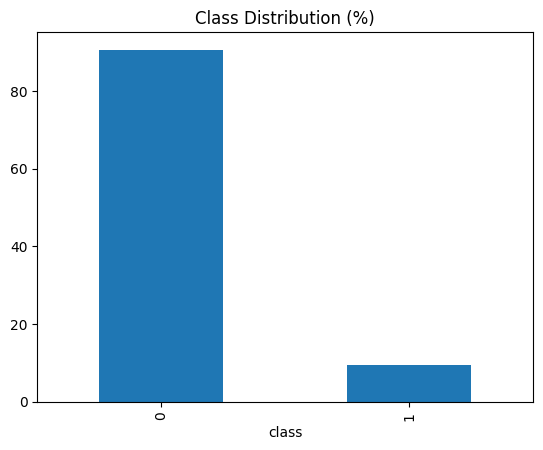

In [21]:
class_dist = fraud_df["class"].value_counts(normalize=True) * 100
print(class_dist)

class_dist.plot(kind="bar", title="Class Distribution (%)")
plt.show()

Univariate Analysis

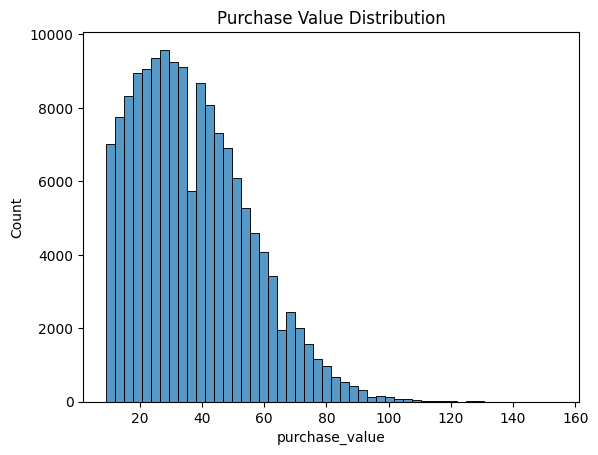

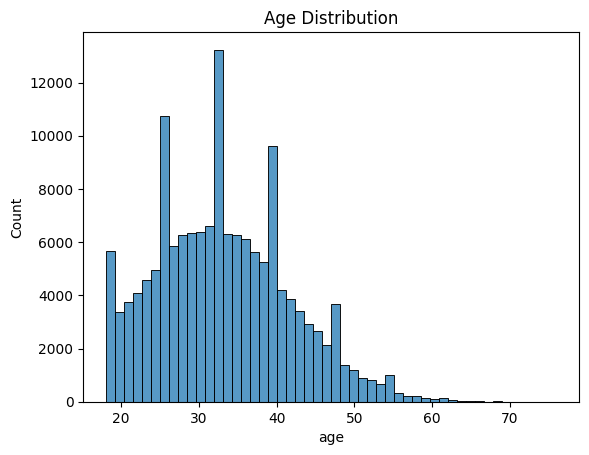

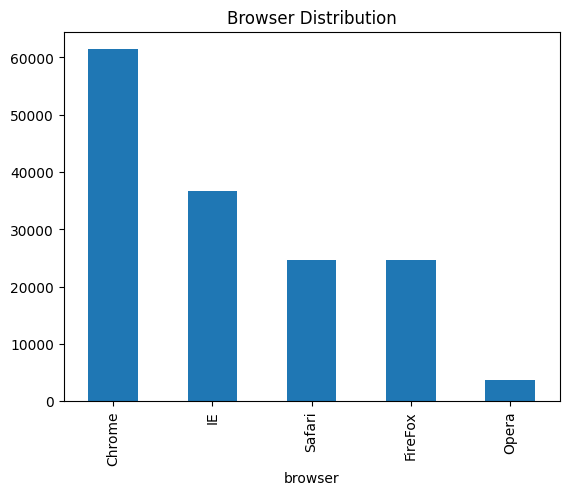

In [23]:
sns.histplot(fraud_df["purchase_value"], bins=50)
plt.title("Purchase Value Distribution")
plt.show()

sns.histplot(fraud_df["age"], bins=50)
plt.title("Age Distribution")
plt.show()

fraud_df["browser"].value_counts().plot(kind="bar")
plt.title("Browser Distribution")
plt.show()

Bivariate Analysis

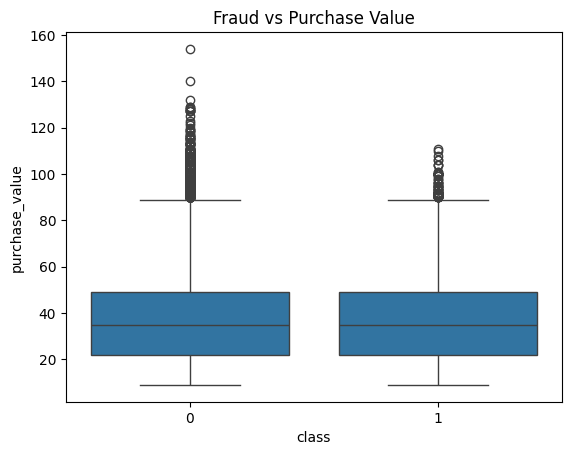

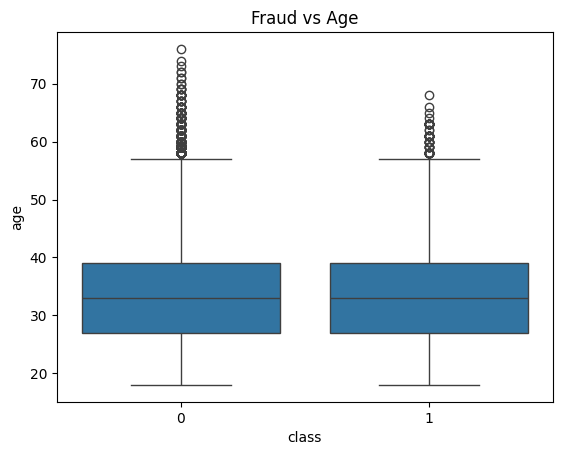

In [24]:
sns.boxplot(x="class", y="purchase_value", data=fraud_df)
plt.title("Fraud vs Purchase Value")
plt.show()

sns.boxplot(x="class", y="age", data=fraud_df)
plt.title("Fraud vs Age")
plt.show()